## Homework 4 - due Friday, February 27th by 4 PM 

Name: Kristen Townsend

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import math
from gaussxw import gaussxw

### Problem 1: Exercise 5.1, page 136

You are determining *displacement* not distance in this problem.

In [ ]:
# part a
# read in the data
vel_data = np.loadtxt("velocities.txt", float)

time = vel_data[:,0]
velocity = vel_data[:,1]

# convert time to integers so it can be used to iterate
new_time = []
for n in range(len(time)):
    new_time.append(int(time[n]))
time = np.array(new_time)

# using the trapezoidal rule
# constants
N = len(time)
a = time[0] # lower bound
b = time[-1] # upperbound
h = (b-a)/N # slice width

# keeping track of displacement
disp = np.zeros(len(time))

# applying the summation
s = 0.5*velocity[a] + 0.5*velocity[b]
for k in range(1, N):
    s += velocity[int(a+k*h)] # must be an int to index
    
    # place total integral value at that point into the displacement array
    disp[k] = (h*s)

# test results
print("The particle travels approximately",h*s, "meters from the starting point.")


The particle travels approximately 8.137548514851503 meters from the starting point.


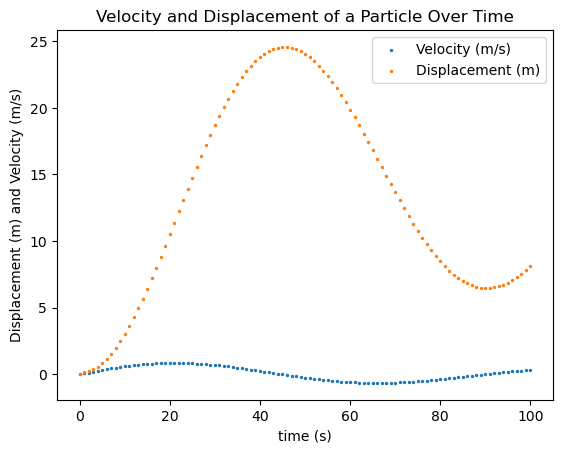

In [44]:
# part b
# defining a distance function


# plotting the velocity curve
plt.scatter(time, velocity, s=2, label='Velocity (m/s)')

# plotting the displacement (not total distance)
plt.scatter(time, disp, s=2, label='Displacement (m)')

# plot labels
plt.title('Velocity and Displacement of a Particle Over Time')
plt.xlabel('time (s)')
plt.ylabel('Displacement (m) and Velocity (m/s)')
plt.legend()
plt.show()

##### Explanation: 

For part (a) I first downloaded/imported everything I needed; velocities.txt and numpy. I then read in the txt file and assigned the variables *time* and *velocity* to each respective column of data. Because velocities.txt is essentially serving as our function being integrated I was able to go direcly into applying the trapezoidal rule to find the integral. The integral of the velocity will give the particle's position.

The trapezoidal rule is as follows:

$$ I(a,b) = h\left[ \frac{1}{2}f(a) + \frac{1}{2}f(b) + \sum_{k=1}^{N-1}f(a+kh)\right] $$

For my N value, I simply used the length of the array of time values, as there cannot be an N greater that that due to the nature of the data provided and I want to remain as precise as possible.

To determine the velocity value for each time stamp, I first had to convert the array of time values into integers so they could be directly referenced when indexing a velocity value. I'm sure there is a cleaner way to do this.

The summation aspect of the trapezoidal rule was relatively straight-forward. I used the range from 1 to N due to the nature of the range() function, and because the summation itself goes from 1 to N-1. I was quickly reminded here that any indexing value must be an integer as well.

To determine the displacement, I initialized an array of zeros and gradually updated each index to be the total value of the integral at that point in time.


For part (b) I imported matplotlib.pyplot and plotted both the velocity and displacement curves with the scatter() function. Both curves were plotted using time and their respective arrays of values. I labeled the axis to the best of my abilities, I'm not entirely sure if the y-axis is labeled correctly or not.


### Problem 2: Exercise 5.3, page 140

In [48]:
# part a
# define the function being integrated
def E(x):
    return np.exp(-x**2)

# Simpsons rule
def simpsons_int(a,b,N,f): 
    # a = lower limit of integration 
    # b = upper limit of integration 
    # N = number of steps 
    # func = function that you are integrating, should be a user-defined function 
    
    # calculate h - width of each step
    h = (b-a) / N

    # evaluate using simpson's rule
    s = f(a) + f(b)
    for k in range(1,N):
        if k%2 == 1: # checking for odd
            s+= 4*f(a+k*h)
        else:
            s += 2*f(a+k*h)
    I = h/3*s

    # return value of the integral 
    return(I)

# constants
a = 0.0
b = 3.0
N = 1000

# compute E(x) from 0 to 3 in steps of 0.1
x_values = np.arange(0, 3.1, 0.1)

# testing function -> it's correct!
result = simpsons_int(a,b,N,E)
print("Integral result:", result)

# test with actual answer
real_result = math.sqrt(math.pi) * math.erf(3) / 2
print("True Int result:", real_result)

Integral result: 0.8862073482595123
True Int result: 0.8862073482595211


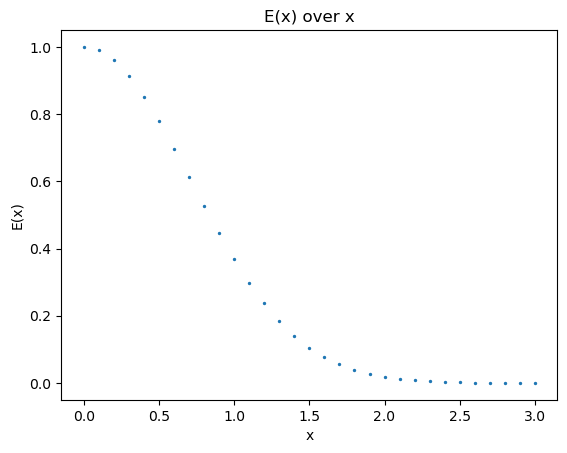

In [ ]:
# part b
# plot it
plt.scatter(x_values, E(x_values), s=2)

# labels
plt.title('E(x) over x')
plt.ylabel('E(x)')
plt.xlabel('x')

plt.show()

#### Explanation: 

For part (a) I began by simply defining the function being integrated $\left( E(x) = \int_{0}^{x} e^{-t^2} dt \right)$ to be used later in the code. I pulled the code we wrote in class for simpson's rule, which works as follows:

$$ I(a,b) = \frac{1}{3}h\left[ f(a) + f(b) + 4\sum_{k \text{ odd}}^{N-1}f(a+kh) + 2\sum_{k \text{ even}}^{N-2}f(a+kh)\right] $$

As shown above, the first and last values of the integration bounds are simply summed together. For any odd values of N from the range() function running from 1 to N-1, the corresponding function value is multiplied by 4. Similarly, for any even values of N, the corresponding function value is multiplied by 2. The result is added to the overall sum.

To compute values of E(x) from 0 to 3 in steps of 0.1, I created an array of values using the arange() function with the bounds of 0 to 3.1, as this function work similarly to the range() function and does not include the upper bound given. 

I did a quick comparison with the integral value given when found with an external tool, and it looks pretty good.

For part (b) I used the array of x values established earlier to create a scatter plot with E(x). Because the x values are in an array, I was able to simply plug the entire array into the function E(x) at once and the calculations were completed on each individual entry in the array of x values. Beyond that, I added some labels and was done!


### Problem 3: Exercise 5.4, page 140

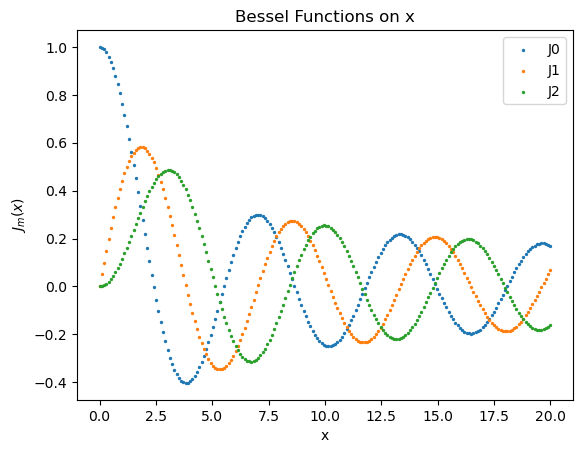

In [55]:
# part a
# function within the integral
def j(theta, m,x):
    return math.cos(m*theta - x*math.sin(theta))

# function for the Bessel function
def J(m,x,j):
    # integrate from 0 to pi
    # bounds
    a = 0
    b = math.pi
    N = 1000
    
    # calculate h - width of each step
    h = (b-a)/N

    # evaluate using simpson's rule
    s = j(a,m,x) + j(b,m,x)
    for k in range(1,N):
        if k%2 == 1: # checking for odd
            s+= 4*j(a+k*h,m,x)
        else:
            s += 2*j(a+k*h,m,x)
    # multiply sum by h/3
    I = h/3*s

    # multiply by 1/pi once integral is done. Return as answer
    return I * 1/math.pi

# an array of x-values
x_vals = np.linspace(0,20,200)

# build arrays of the Bessel funcs J0, J1, and J2
# array for J0
J0_array = np.zeros(len(x_vals))
for i in range(len(J0_array)):
    J0_array[i] = J(0, x_vals[i], j) # m, x, j(function)

# array for J1
J1_array = np.zeros(len(x_vals))
for i in range(len(J1_array)):
    J1_array[i] = J(1, x_vals[i], j) # m, x, j(function)

# array for J2
J2_array = np.zeros(len(x_vals))
for i in range(len(J2_array)):
    J2_array[i] = J(2, x_vals[i], j) # m, x, j(function)

# plot them
plt.scatter(x_vals, J0_array, s=2, label="J0")
plt.scatter(x_vals, J1_array, s=2, label="J1")
plt.scatter(x_vals, J2_array, s=2, label="J2")

# extra plot details
plt.title("Bessel Functions on x")
plt.ylabel("$J_m(x)$")
plt.xlabel("x")
plt.legend()

plt.show()

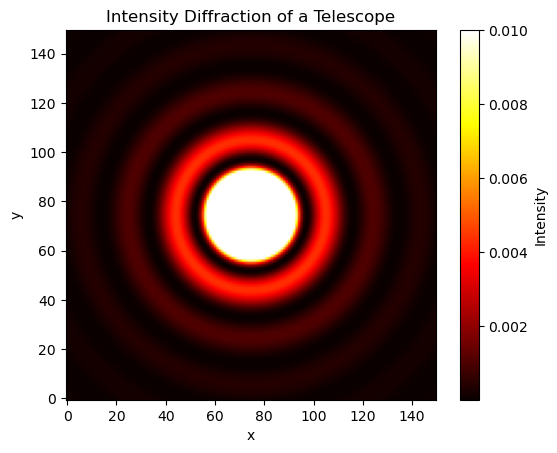

In [59]:
# part b
# define function for the intensity
def I(r):
    # constants
    I0 = 1 # an assumption
    L = 500e-9 #meters
    k = 2*math.pi / L

    # makes plugging everything in a bit easier
    x = k*r

    # call Bessel function to find J1(kr)
    J1 = J(1, x, j) # m, x, j(function)

    # avoid dividing by zero
    if r < 1e-10:
        Intensity = I0 * (1/2)**2 # using time lim->0 J(x)/x = 1/2
    else:
        Intensity = I0 * (J1/x)**2

    return Intensity

# values for x, y grid
extent = 1e-6 #meters
N = 150

x = np.linspace(-extent, extent, N)
y = np.linspace(-extent, extent, N)

# initializing a 2D array of zeros to hold I(r) results
Intensity = np.zeros((len(x),len(y)))

# loop through points to fill previous array
for i in range(N):
    for k in range(N):
        # find r for coordinates x, y
        r = math.sqrt(x[i]**2 + y[k]**2)
        # Bessel
        Intensity[k, i] = I(r) # row, column

# plotting details
plt.imshow(Intensity, origin="lower", vmax = 0.01) # limiting center intensity so the outer rings are visible
plt.hot()
plt.colorbar(label="Intensity")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Intensity Diffraction of a Telescope")

plt.show()

#### Explanation: 

For part (a) I defined two functions; one of the function being integrated with simpson's rule and the other which applies the simpson's rule itself. The full equation, also known as a Bessel function, that calculated is as follows:

$$ J_m(x) = \frac{1}{\pi} \int_{0}^{\pi} \cos( m\theta - x\sin\theta) d\theta. $$

The "sub-function" I defined was $\cos( m\theta - x\sin\theta).$ The integral was completed using the same method as Exercise 2 of this homework. The first and last values of the integration bounds are simply summed together. For any odd values of N from the range() function running from 1 to N-1, the corresponding function value is multiplied by 4. Similarly, for any even values of N, the corresponding function value is multiplied by 2. The result is added to the overall sum.

As specified in the problem, I used $N = 1000$ steps and multiplied the final summation by $1/\pi$ to complete the Bessel function. I imported math to do so for no particular reason other than I felt it would be lonely if I only used numpy. 

To make arrays of values given by the Bessel functions $J_0$, $J_1$, and $J_2$, I first initialized an array of x-values from $x = 0$ to $x = 10$. For each of the three functions I created an array of zeros the same length as my x-values, and filled them using a loop iterating over all x-values that calculates the function value at each x using my previously defined J() function. These values were then stored within the respective Bessel function array at the matching index.

All three were plotted using the scatter() function against the array of x-values. I included lables and a color legend for clarity.


For part (b) I began by defining the function I(r) to calculate the intensity of light by the following:

$$ I(r) = I_0 \left(\frac{J_1(kr)}{kr}\right)^2 $$

For this scenario, the wavelength $\lambda = 500$ nm was used within $k = 2\pi / \lambda$ along with the constant $I_0$, distance from the focal point $r$, and the Bessel function $J_1$. All measurements involved were converted into meters to prevent any strange scaling difficulties. Within my function I include an important condition to prevent division by zero. Using the tips given in our text book alongside the problem, any r-value less that $10^{-10}$ from zero is automatically determined to equal $1/2.$

To create the density plot, I initialized two arrays; one for the x-direction and one for the y-direction, with the extent reaching 1 $\mu\text{m}$ from the focal point. I then created a 2D array of zeros to hold the intensity results, and then filled the array using a nested for loop to reach each index. At each index, the value of the previously defined function I(r) was calulated and stored. The radius $r$ was found using $r = \sqrt{x^2 + y^2}$ for each index location given by the two direction arrays.

The array of intensity values was then plotted using the imshow() function. I reduced the maximum value visible and used the 'hot' color scheme for visibility, as recommended by the book. Axis labels, a colorbar, and a title were then added for clarity.


### Problem 4: Exercise 5.6, page 146

In [54]:
# Pulled from book example 5.1
def f(x):
    return x**4 - 2*x + 1

# integration bounds
a = 0.0
b = 2.0

# different N values
N1 = 10
N2 = 20

h1 = (b-a)/N1
h2 = (b-a)/N2

# apply trapezoidal rule
# N = 10
s1 = 0.5*f(a) + 0.5*f(b)
for k in range(1,N1):
    s1 += f(a+k*h1)
integral1 = h1*s1

# N = 20
s2 = 0.5*f(a) + 0.5*f(b)
for k in range(1,N2):
    s2 += f(a+k*h2)
integral2 = h2*s2

# approximation error
delta = abs(integral2 - integral1) / 3

# value error
# actual integral value
real_val = 4.4
approx1 = abs(real_val - integral1)
approx2 = abs(real_val - integral2)

# print results
print("Calculated error of", delta)
print("Error from the true value at N = 10:", approx1)
print("Error from the true value at N = 20:", approx2)

Calculated error of 0.026633333333333137
Error from the true value at N = 10: 0.10655999999999999
Error from the true value at N = 20: 0.026660000000000572


#### Explanation: 

For the bulk of the code I was able to pull it directly from book Example 5.1, as recommended in the text. I evaluated the integral twice, once using $N_1 = 10$ slices and then again using $N_2 = 20$ slices. I then calculated the error with the following:

$$\delta = \frac{1}{3}(I_2 - I_1).$$

How does the delta error compare with direct computation of the error? Why do the two not agree perfectly?

Most importantly, $\delta$ is an *estimation* of the uncertainty based on how the trapezoidal rule error is *expected* to behave. It comes from a Taylor expansion of higher-order terms.

At smaller step sizes of h (more N slices), the extra terms in the Taylor expansion get smaller and the estimate becomes more accurate.

This can be easily seen with the uncertainty value for $N_2$ slices being much closer to the calculated $\delta$ error than the uncertainty values for $N_1$ slices.


### Problem 5: Exercise 5.9, page 165

In [ ]:
# part a
def cv(T):
    # constants
    V = 3000 #cm
    rho = 6.022e28 #m^{-3}
    D = 428 # Debye temperature
    kb = 1.381e-23 # boltzmann constant, J per K

    ### Integration part ###
    # integration constants
    N = 50
    a = 0
    b = D / T

    # calculate the sample points and weights
    x,w = gaussxw(N,a,b)

    # perform the integration
    s = 0.0
    for k in range(N):
        s += w[k]*f(x[k])
    
    # multiply with the rest of the equation
    CV = s * (9*V*rho*kb*(T/D)**3)

    return CV


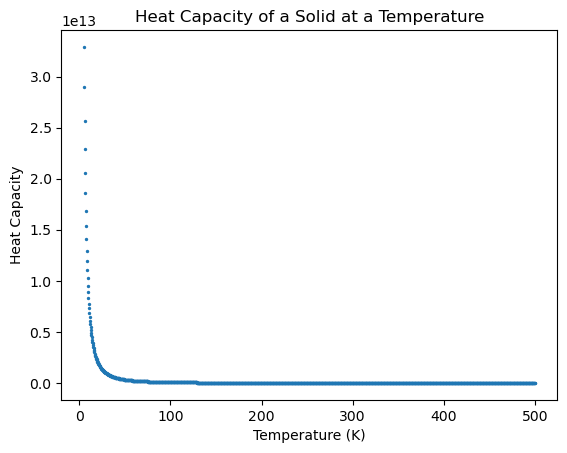

In [ ]:
# part b
# temperatures from 5K to 500K
temp = np.linspace(5, 500, 1500)

# array for heat capacity
heat_capacity = np.zeros(len(temp))
for i in range(len(heat_capacity)):
    heat_capacity[i] = cv(temp[i])

# plot!
plt.scatter(temp, heat_capacity, s=2)
plt.xlabel("Temperature (K)")
plt.ylabel("Heat Capacity")
plt.title("Heat Capacity of a Solid at a Temperature")
plt.show()

#### Explanation: 

Gaussian Quadrature, yay.

For part (a), I defined the function cv(T), as specifically requested in the book. Within the function itself I created variables for all the constants used in the following equation for heat capacity of a solid at temperature T:

$$ C_V = 9 V \rho k_B \left(\frac{T}{\theta _D}\right)^3 \int_{0}^{\theta_D / T} \frac{x^4 e^x}{(e^x - 1)^2} dx. $$

I then established my integration bounds and step size, and calculated the sample points and their respective weights using the gaussxw.py file that is imported into the notebook above.

After summing over all of the calculations $w[k] f(x[k])$ for k by iterating through all values of N-1, the summation was then multiplied by the constants remaining in the equation.


For part (b) I created an array of temperature values from 5K to 500K with the linspace() function. I set the number of steps within the array relatively high, as I wanted to show the sharp curve in the beginning of the plot clearly. I then initialized an array of zeros the same length as the temperature values array to hold the calculated heat capacities.

To fill the previous array, a loop iterates over all temperature values, calculates the heat capacity at each temperature using the previously defined cv(T), and then stores it within the the heat capacity array at the matching index.

Plotting was done with the scatter() function using both the time and heat capacity arrays. Labels were added to the respecive axis.